# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from AFL.double_agent import *
from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 

from typing import Optional, Union, List, Tuple, Dict
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import matplotlib.transforms as mtransforms 
from matplotlib.colors import Normalize 

In [3]:
import sys
import os
folders = [os.path.abspath("../modules/"), os.path.abspath("../dataset/")]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

from cost import DesignSpaceHierarchyCost, BinaryProbabilityCost, UtilityWithCost, MarginalCost, SlicedCost
from utility import MarginalEntropyAlongDimension, MarginalEntropyOverDimension 
from query_strategy import ArgMax, FullWidthHalfMaximum1D 
from VirtualSAS_theory import VirtualSAS_theory

### Create Virtual Instrument

In [ ]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

boundary_dataset = xr.load_dataset('../dataset/250610-extrap_expand_dataset.nc')
boundary_dataset.close()

reference_data_path = '../dataset/SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)

# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

### initial Dataset

In [5]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds['step'] = 0
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:       (sample: 6, q: 281, ds_dim: 3)
Coordinates:
  * q             (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * ds_dim        (ds_dim) <U11 132B 'protein' 'temperature' 'glycerol'
Dimensions without coordinates: sample
Data variables:
    I             (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    I_noiseless   (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    dI            (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    design_space  (sample, ds_dim) int64 144B 40 0 5 40 10 5 ... 40 40 5 40 50 5
    phases        (sample) int64 48B 2 1 1 1 0 0
    step          (sample) int64 48B 0 0 0 0 0 0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

### Modeling unknown feasibility constraints

In [6]:
class FeasibilityLabeler(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        output_variable: str = None,
        dim: str = "sample",
        name: str = "FeasibilityLabeler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=input_variable, 
            output_variable=output_variable,
        )
        self.dim = dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Label samples as feasible or infeasible based on cost."""
        labels = dataset[self.input_variable].values
        is_feasible = np.where(labels == 0, 0, 1)  # 1 for feasible, 0 for infeasible
        self.output[self.output_variable] = xr.DataArray(is_feasible, dims=[self.dim])
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Feasibility labels based on {self.input_variable}"

        return self

### Creatte the pipeline for active learning

In [7]:
gp_params_mcmc = {"num_samples":20, "num_warmup":20, "method":"mcmc", "verbose":False}

In [8]:
with Pipeline(name = "phase_boundaries") as p:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phase",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-PhaseLabels",
    )
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    MarginalEntropyOverDimension(
        input_variable= "phase_y_prob",
        coordinate_dims= ['temperature'],
        component_dim= "ds_dim",
        grid_variable= "design_space_grid",        
        output_variable="composition_utility",
        name= "UtilityMarginalEntropy",
    )
    DesignSpaceHierarchyCost(
        input_variable = "normalized_design_space_grid",
        grid_variable = "design_space_grid",
        grid_dim = "ds_grid",
        component_dim = "ds_dim",
        coordinates_order = ['temperature', 'protein', 'glycerol'], # from highest to lowest cost
        coordinates_offsets = [0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name = "DesignSpaceHierarchyCost",        
    )
    MarginalCost(
        input_variable = "hierarchy_cost",
        coordinate_dims = ['temperature'],
        component_dim = "ds_dim",
        grid_variable = "design_space_grid",
        output_variable="composition_hierarchy_cost",
        name= "MarginalCost",
    )    
    UtilityWithCost(
        input_variable = "composition_utility",
        cost_variables = ["composition_hierarchy_cost"],
        output_variable = "composition_utility_with_cost",
        name = "AcquisitonWithCost-Composition",
    )
    ArgMax(
        input_variable="composition_utility_with_cost",
        grid_variable="_".join(i for i in ['protein', 'glycerol'])+"_domain",
        output_prefix= "composition",
        name= "QueryStrategyCompositionSpace",
    )
    MarginalEntropyAlongDimension(
        input_variable= "phase_y_prob",
        conditioning_point= "composition_next",
        coordinate_dim= "temperature",
        grid_variable= "design_space_grid",        
        component_dim= "ds_dim",
        output_variable="temperature_utility",
        name= "MarginalEntropyAlongDimension",
    )
    BinaryProbabilityCost(
        input_variable="feasibility_y_prob",
        grid_variable = "design_space_grid",
        cost_label = 0,
        dim="ds_grid",
        output_variable = "feasibility_cost",
        name = "BinaryProbabilityCost"
    )
    SlicedCost(
        input_variable = "feasibility_cost",
        conditioning_point = "composition_next",
        coordinate_dim = "temperature",
        grid_variable = "design_space_grid",        
        component_dim = "ds_dim",
        output_variable = "temperature_cost",
        name = "SlicedCost",
    )    
    UtilityWithCost(
        input_variable = "temperature_utility",
        cost_variables = ["temperature_cost"],
        output_variable = "temperature_utility_with_cost",
        name = "AcquisitonWithCost-Temperature",
    )    
    FullWidthHalfMaximum1D(
        input_variable= "temperature_utility_with_cost",
        grid_variable = "temperature_domain",
        output_prefix= "temperature",
        name= "FullWidthHalfMaximum1D",
    )
    

p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize>                       design_space_grid ---> normalized_design_space_grid
3  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phase_y_prob']
4  ) <FeasibilityLabeler>                phases ---> feasibility_labels
5  ) <DirichletGPExtrapolator-FeasibilityLabels> ['normalized_design_space', 'feasibility_labels', 'normalized_design_space_grid'] ---> ['feasibility_y_prob']
6  ) <UtilityMarginalEntropy>            phase_y_prob ---> composition_utility
7  ) <DesignSpaceHierarchyCost>          normalized_design_space_grid ---> hierarchy_cost
8  ) <MarginalCost>                      hierarc

In [9]:
ds_result = p.calculate(ds_init)
ds_result

  0%|          | 0/16 [00:00<?, ?it/s]

<xarray.Dataset> Size: 1MB
Dimensions:                        (q: 281, ds_dim: 3, sample: 6,
                                    ds_grid: 8000, phase_n_classes: 3,
                                    feasibility_n_classes: 2,
                                    protein_glycerol_n: 400,
                                    protein_glycerol_d: 2,
                                    composition_next_n: 1, temperature_n: 20,
                                    temperature_next_n: 1)
Coordinates:
  * q                              (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                         (ds_dim) object 24B 'protein' ... 'glycerol'
  * protein_glycerol_d             (protein_glycerol_d) <U8 64B 'protein' 'gl...
Dimensions without coordinates: sample, ds_grid, phase_n_classes,
                                feasibility_n_classes, protein_glycerol_n,
                                composition_next_n, temperature_n,
                                temperature_next_n
Data variables: (12/30)
    I                              (sample, q) float64 13kB 1.95 1.937 ... 1.0
    I_noiseless                    (sample, q) float64 13kB 1.95 1.937 ... 1.0
    dI                             (sample, q) float64 13kB 0.0 0.0 ... 0.0 0.0
    design_space                   (sample, ds_dim) int64 144B 40 0 5 ... 50 5
    phases                         (sample) int64 48B 2 1 1 1 0 0
    step                           (sample) int64 48B 0 0 0 0 0 0
    ...                             ...
    temperature_utility            (temperature_n) float64 160B 1.061 ... 1.057
    temperature_domain             (temperature_n) float64 160B 0.0 ... 50.0
    feasibility_cost               (ds_grid) float64 64kB 0.2885 ... 0.517
    temperature_cost               (temperature_n) float64 160B 0.2885 ... 0....
    temperature_utility_with_cost  (temperature_n) float64 160B 0.7549 ... 0....
    temperature_next               (temperature_next_n) float64 8B 0.0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [10]:
class ExperimentCost(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        input_dim : str = None,
        composition_dims_cost :  Dict = None,
        temperature_dim_cost: Dict[str, float] = None,
        output_variable: str = None,
        name: str = "ExperimentCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=input_variable, output_variable=output_variable
        )
        self.composition_dims_cost = composition_dims_cost
        self.temperature_dim_cost = temperature_dim_cost
        self.input_dim = input_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        data = dataset[self.input_variable]
        expense = 0.0

        # Compute cost of using sample stocks
        composition_names = [key for key in self.composition_dims_cost.keys()]
        compositions = data.sel({self.input_dim:composition_names}).values
        _, indices = np.unique(compositions, axis=0, return_index=True)
        for name, val in self.composition_dims_cost.items():
            sampled_quantity = data.sel({self.input_dim:name}).values
            expense += (sampled_quantity[indices]*val).sum()

        # Compute cost of temperature modulation
        name, val = next(iter(self.temperature_dim_cost.items()))
        sampled_temperatures = data.sel({self.input_dim:name}).values
        for i in range(sampled_temperatures.shape[0]):
            if i>=1:
                expense += val*np.abs(sampled_temperatures[i] - sampled_temperatures[i-1])
            else:
                expense += val*np.abs(sampled_temperatures[i] - 27.0)

        # Store result
        output = xr.DataArray(expense)
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = "Total cost current experiment took so far."

        return self 
    
expense = ExperimentCost(
        input_variable="design_space",
        input_dim="ds_dim",
        composition_dims_cost={"protein":10.0, "glycerol" :5.0},
        temperature_dim_cost={"temperature" : 20.0},
        output_variable="expense",
        name="ExperimentCost"
    )

In [11]:
def plot_progress(ds, 
                  design_space_variable, 
                  grid_variable, 
                  design_space_dim, 
                  composition_variables,
                  temperature_variable,
                  labels_variable,
                  phase_probability_variable,
                  feasibilty_probability_variable
                  ):
    """Plot cost and entropy in 3D."""
    fig, axs  = plt.subplots(1,3, 
                             figsize=(4*3, 4*1), 
                             subplot_kw={"projection":'3d'},
                             )
    axs = axs.flatten()
    fig.subplots_adjust(wspace=0.5, hspace=0.5)

    ax = axs[0]
    x = ds[design_space_variable].sel({design_space_dim:composition_variables[0]}).values
    y = ds[design_space_variable].sel({design_space_dim:composition_variables[1]}).values
    z = ds[design_space_variable].sel({design_space_dim:temperature_variable}).values
    ax.scatter(x, y, z, c=ds[labels_variable].values)
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)

    xg = ds[grid_variable].sel({design_space_dim:composition_variables[0]}).values
    yg = ds[grid_variable].sel({design_space_dim:composition_variables[1]}).values
    zg = ds[grid_variable].sel({design_space_dim:temperature_variable}).values    

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax = axs[1]
    mappable = ax.scatter(xg, yg, zg,
        c=ds[phase_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(phase_probability_variable)

    ax = axs[2]
    mappable = ax.scatter(xg, yg, zg,
        c=ds[feasibilty_probability_variable].values[:,1],
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(feasibilty_probability_variable)

    for ax in axs:
        ax.set_xlabel(composition_variables[0])
        ax.set_ylabel(composition_variables[1])
        ax.set_zlabel(temperature_variable, labelpad=-2)
    plt.tight_layout()

    return fig, axs

In [14]:
def plot_sampling(ds):
    fig = plt.figure(figsize=(10, 5))
    gs = gridspec.GridSpec(nrows=2, 
                        ncols=2, 
                        height_ratios=[0.05, 0.95], 
                        hspace=0.05, wspace=0.25)

    ax_cb = fig.add_subplot(gs[0, 0])       # colorbar axis above left plot
    ax_comp = fig.add_subplot(gs[1, 0])      # 2D KDE plot
    ax_temp = fig.add_subplot(gs[1, 1])     # 1D KDE plot

    ux = ds["composition_utility_with_cost"].values
    x = ds["protein_glycerol_domain"].values
    mappable = ax_comp.tricontourf(x[:,0], x[:,1], ux)
    cbar = fig.colorbar(mappable, cax=ax_cb, orientation='horizontal')
    cbar.set_label(r"$\sum_{t}u(x,t)$", labelpad=15)
    ax_cb.xaxis.set_ticks_position('top')
    ax_cb.xaxis.set_label_position('top')

    ax_comp.scatter(ds.design_space.sel({"ds_dim":"protein"}).values ,
            ds.design_space.sel({"ds_dim":"glycerol"}).values,
            color = "k"
        )
    ax_comp.scatter(ds.composition_next.sel({"protein_glycerol_d":"protein"}).values ,
            ds.composition_next.sel({"protein_glycerol_d":"glycerol"}).values,
            color = "tab:red",
        )
    ax_comp.set_xlim([0.0, 80.0])
    ax_comp.set_ylim([0.0, 12.0])
    ax_comp.set_xlabel("protein")
    ax_comp.set_ylabel("glycerol")

    ax_temp.plot(
        ds.temperature_domain.values,
        ds.temperature_utility_with_cost.values,
        )
    t_opt = ds.temperature_next.values 
    for ti in t_opt:
        ax_temp.axvline(ti, ls='--', color="k")
    ax_temp.set_xlabel("Temperature")
    ax_temp.set_ylabel(r"$v(t)$")
    

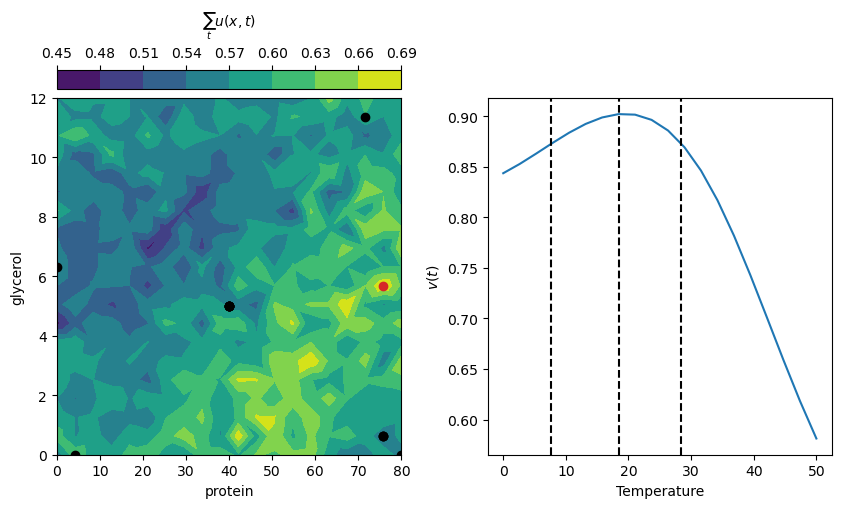

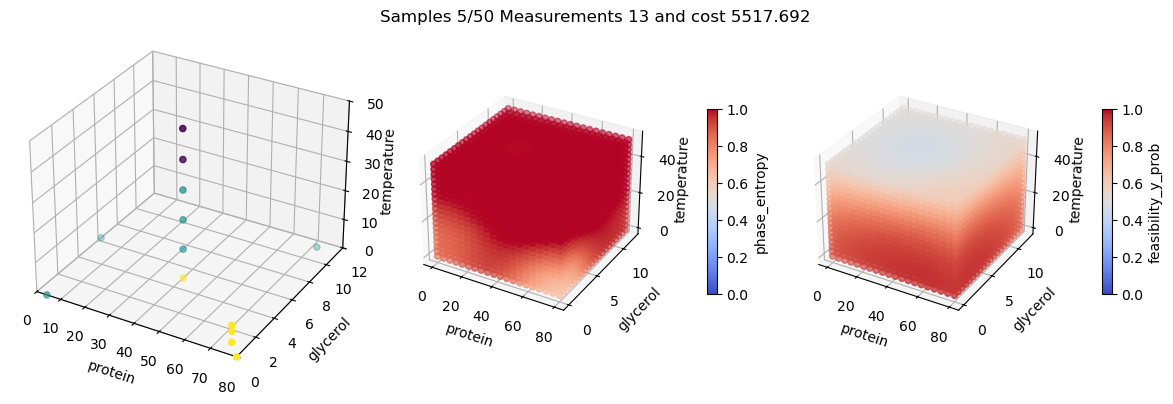

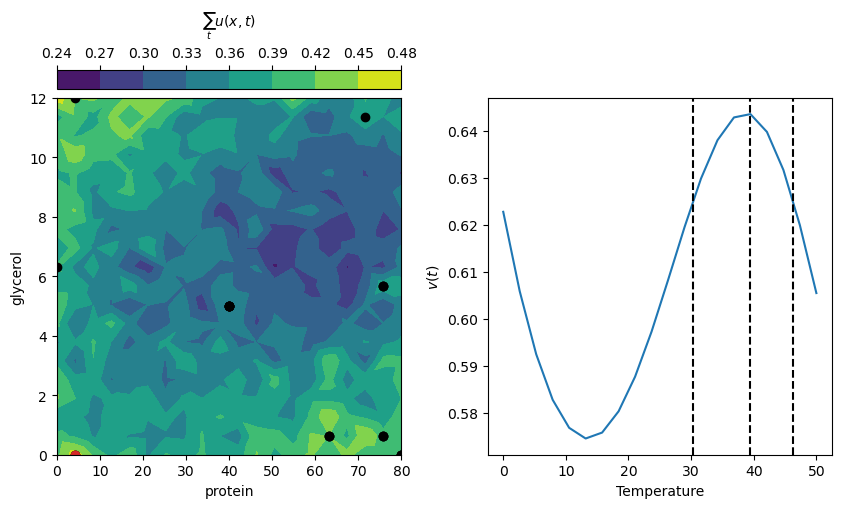

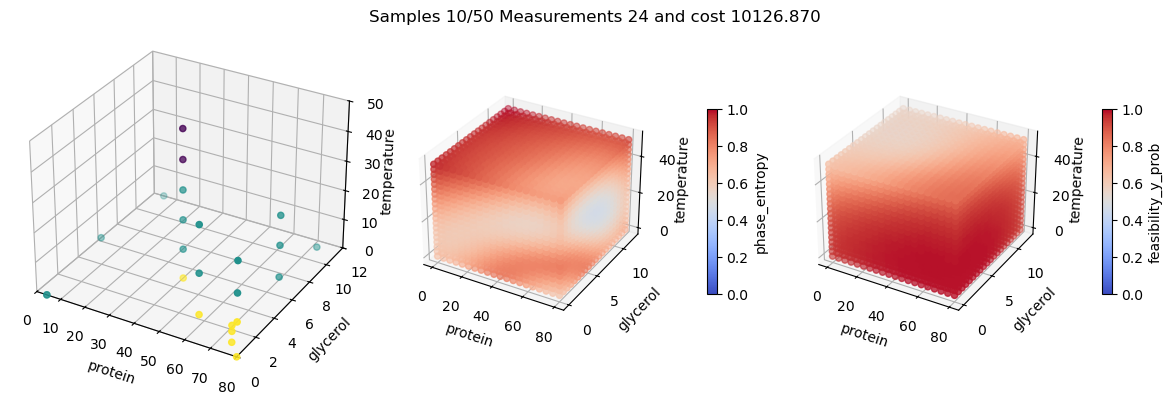

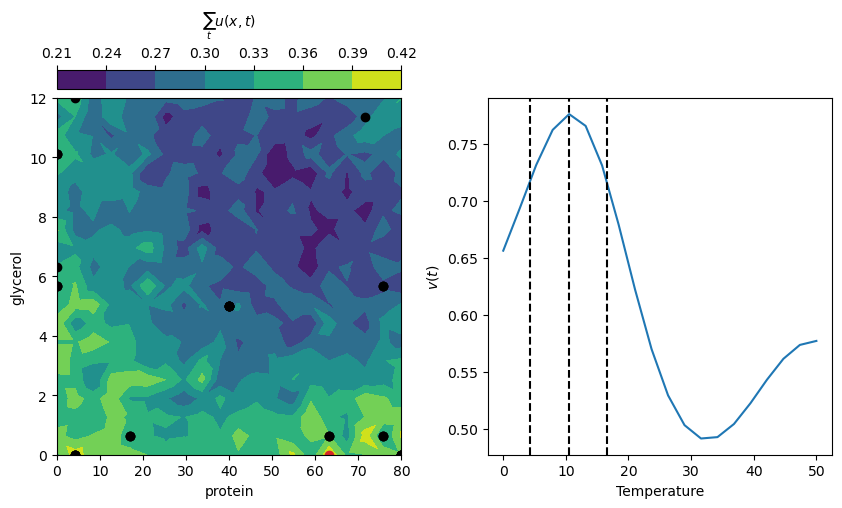

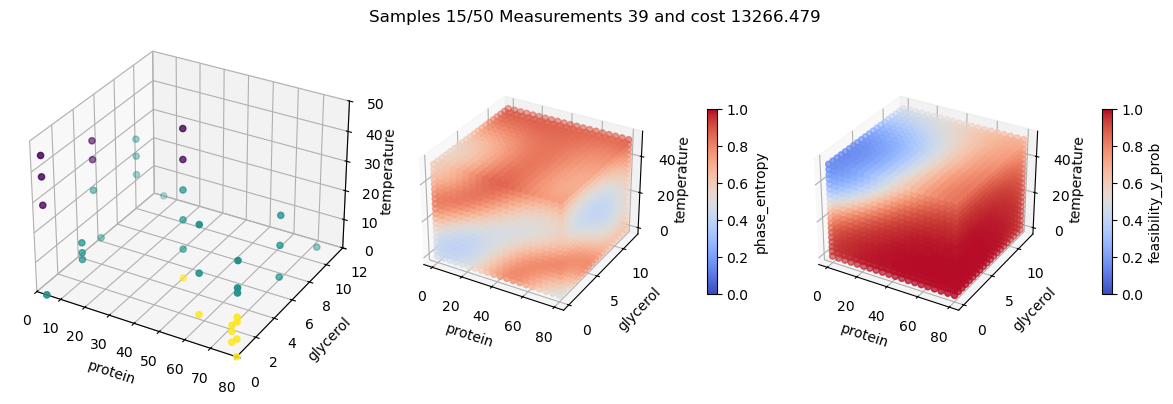

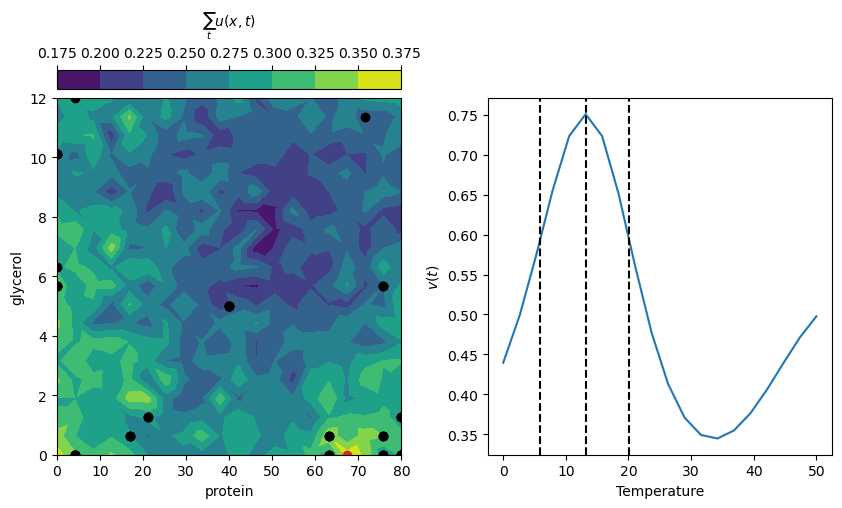

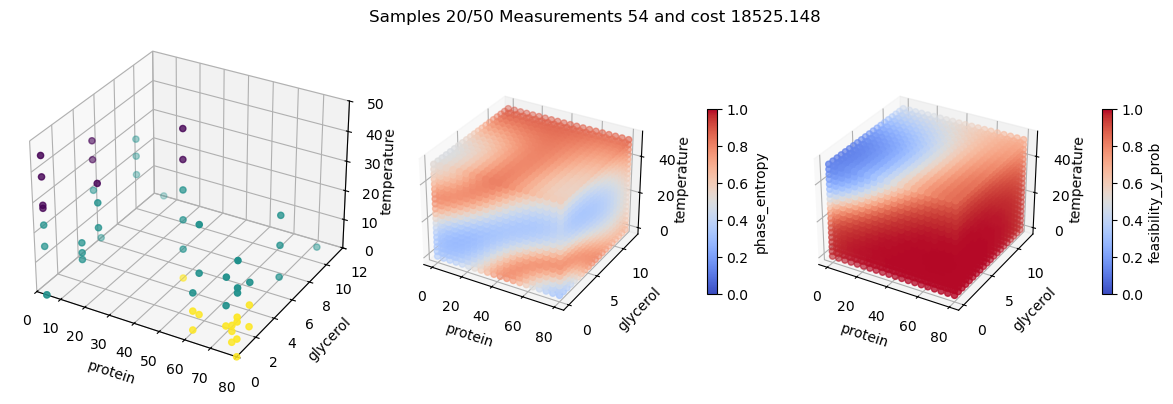

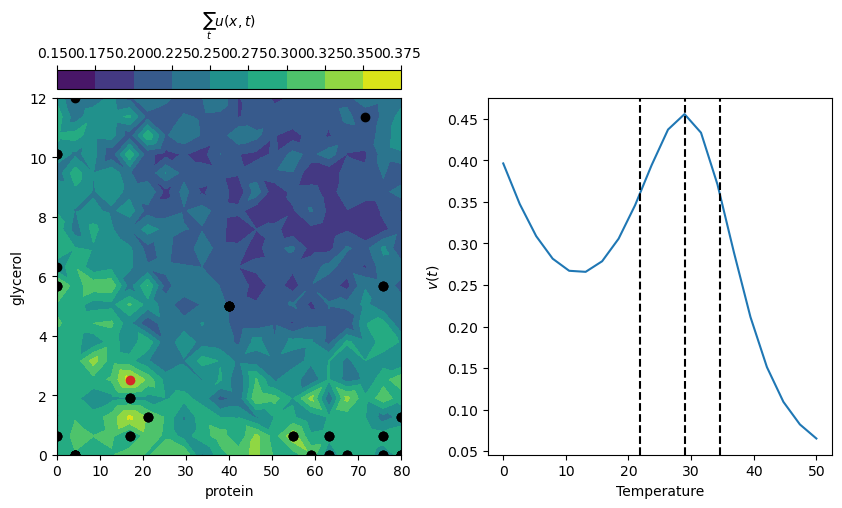

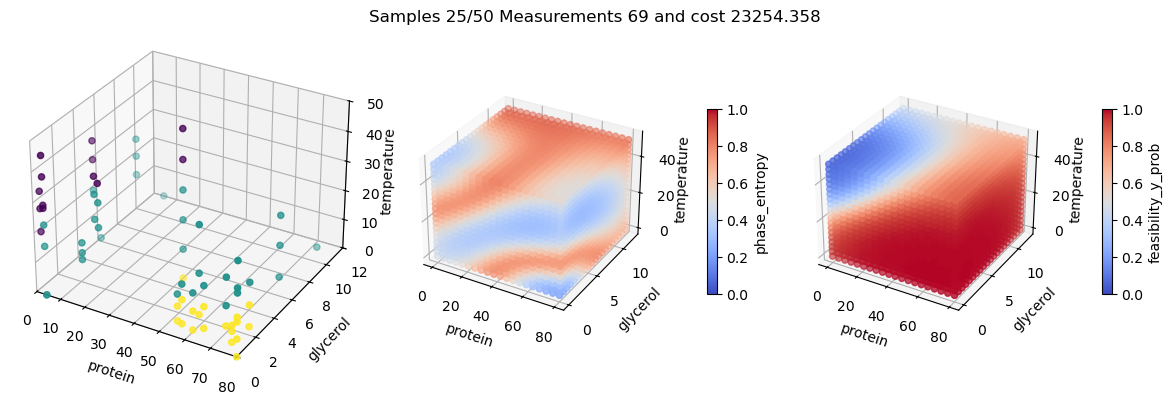

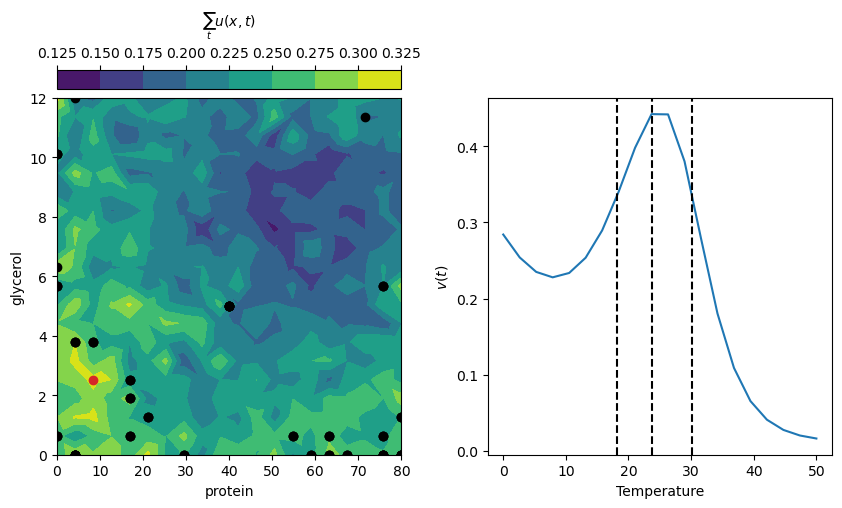

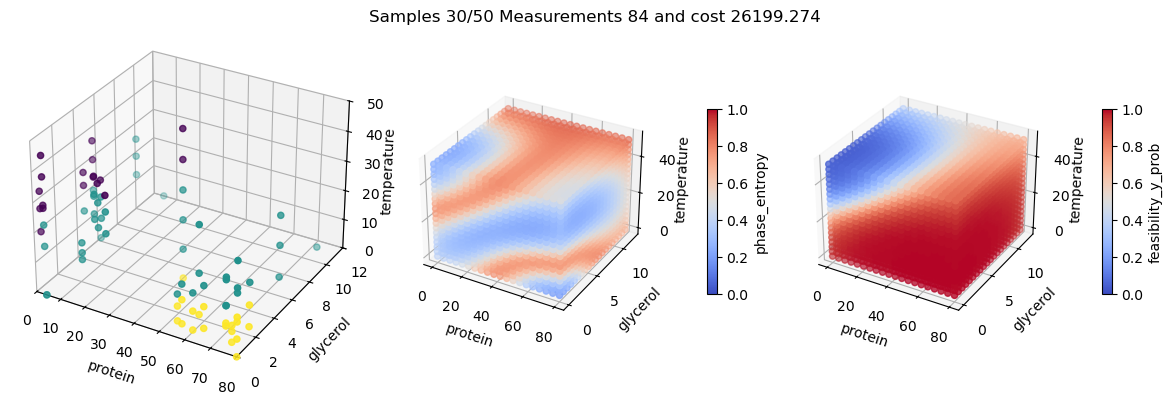

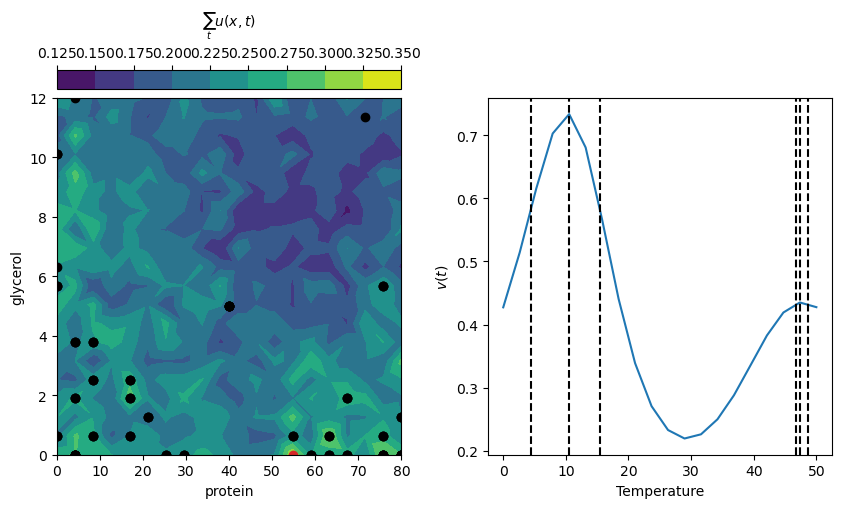

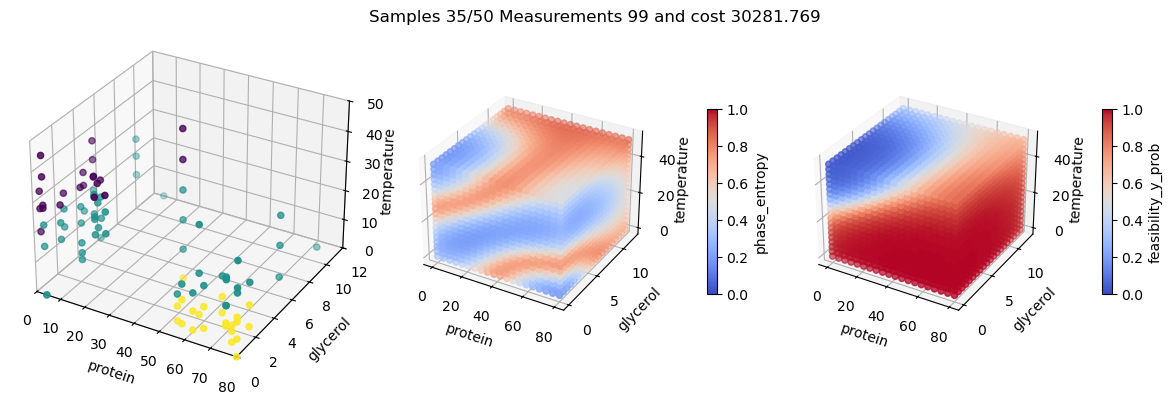

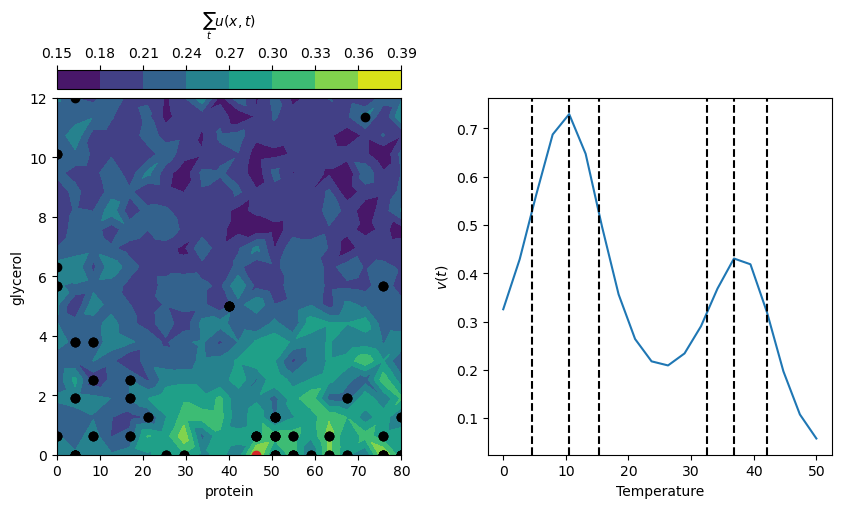

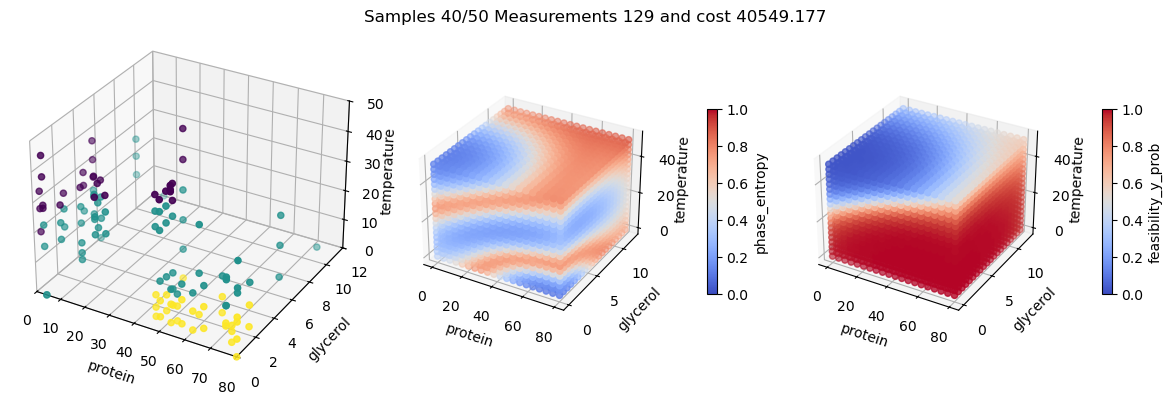

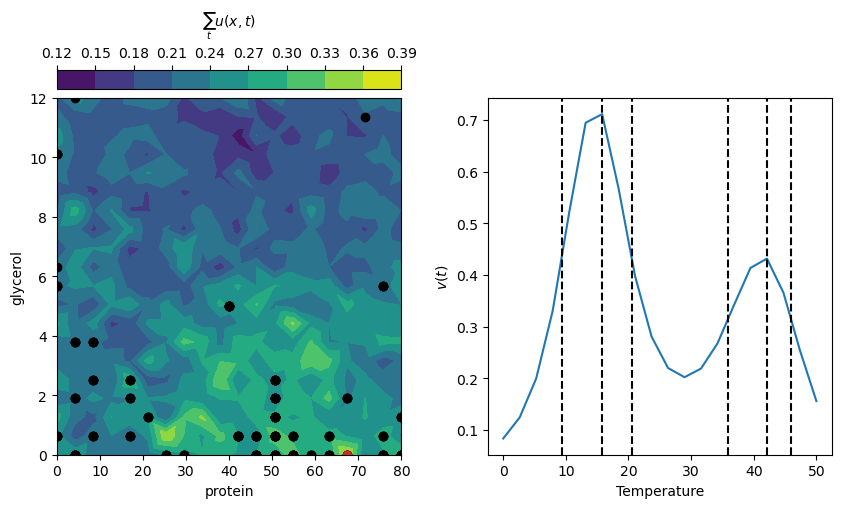

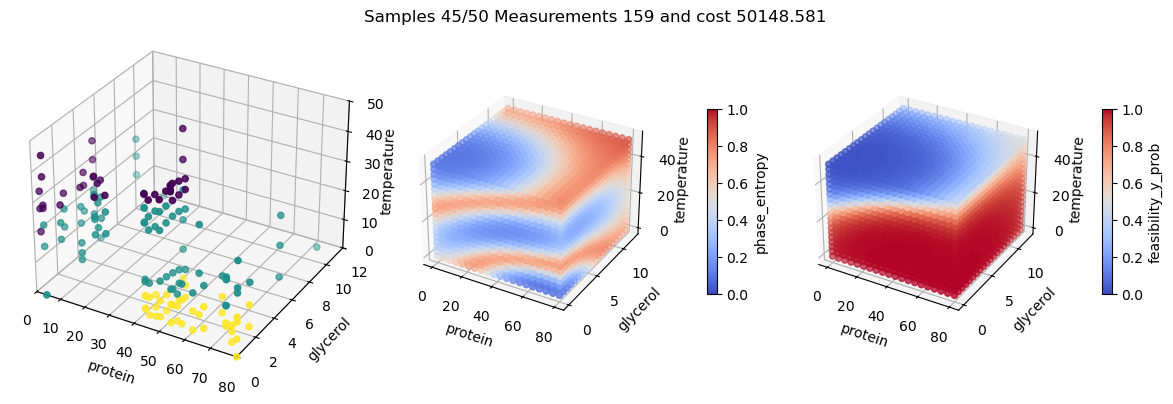

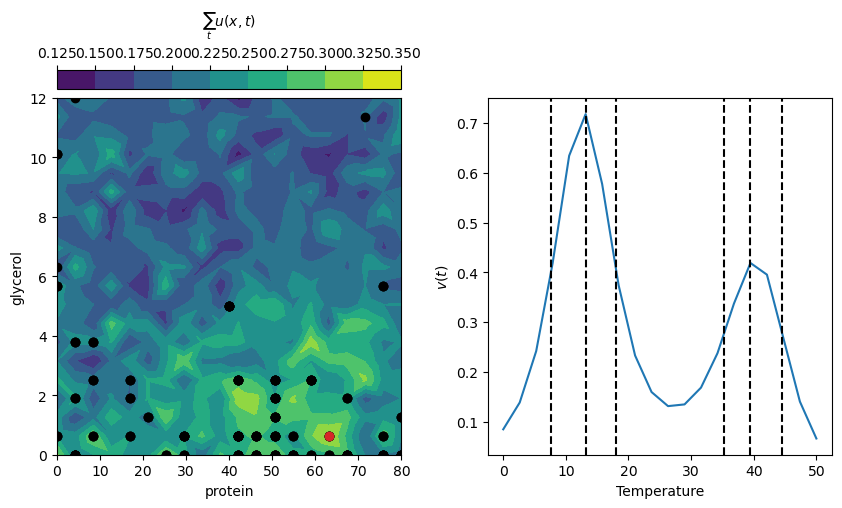

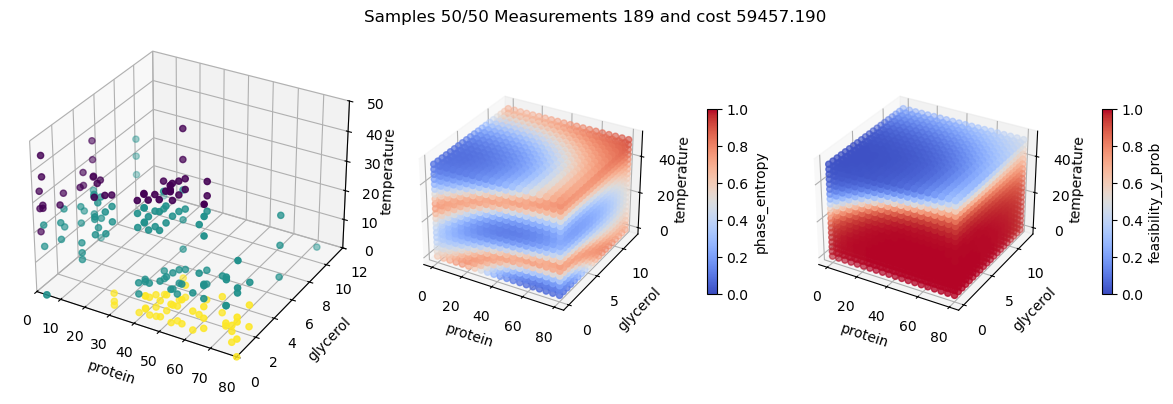

In [15]:
ds_running = ds_init.copy() 
ds_result = p.calculate(ds_init, disable_progress_bar=True)
n_samples = 50
step = 0
for step in range(n_samples):
    ds_new = []
    for t in ds_result.temperature_next.values:
        sample = {"protein": ds_result.composition_next.sel({"protein_glycerol_d":"protein"}).values.item(),
                "glycerol" : ds_result.composition_next.sel({"protein_glycerol_d":"glycerol"}).values.item(),
                "temperature" : t.item()
        }  
        ds = inst_client.simple_expose(sample)
        ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
        ds['phases'] = int(ds.attrs['labels'])
        ds_new.append(ds)

    ds_new = xr.concat(ds_new, dim='sample')
    ds_running = xr.concat([ds_running, ds_new], dim='sample')
    ds_result = p.calculate(ds_running, disable_progress_bar=True)
    out = expense.calculate(ds_running)
    if (100*((step+1)/n_samples))%10==0:
        plot_sampling(ds_result)
        plt.show()
        
        fig, axs = plot_progress(ds_result, 
                    "design_space", 
                    "design_space_grid", 
                    "ds_dim", 
                    ['protein', 'glycerol'],
                    "temperature",
                    "phases",
                    "phase_entropy",
                    "feasibility_y_prob"
                )
        fig.suptitle(f"Samples {step+1}/{n_samples} Measurements {len(ds_running.sample)} " + 
                    f"and cost {out.output['expense'].values.item():.3f}")
        plt.show()

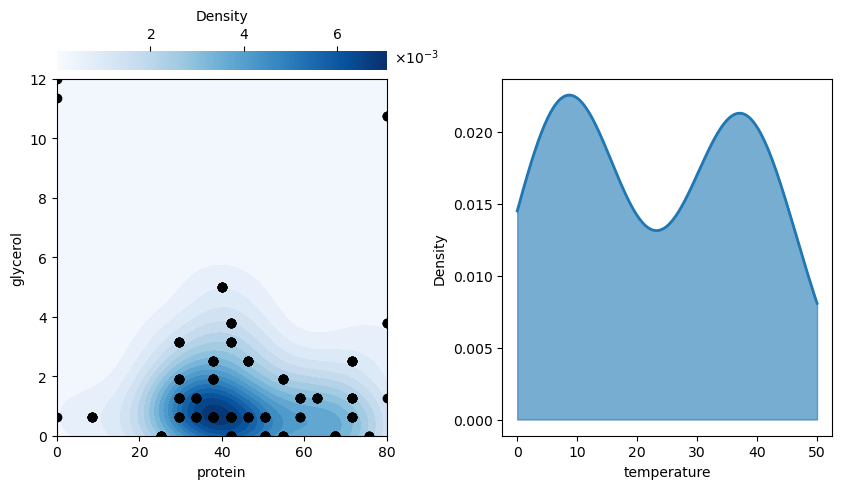

In [ ]:
design_space_variable = "design_space"
design_space_dim = "ds_dim"
composition_variables = ["protein", "glycerol"]
temperature_variable = "temperature"

x = ds_running[design_space_variable].sel({design_space_dim: composition_variables[0]}).values
y = ds_running[design_space_variable].sel({design_space_dim: composition_variables[1]}).values
z = ds_running[design_space_variable].sel({design_space_dim: temperature_variable}).values

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(nrows=2, 
                       ncols=2, 
                       height_ratios=[0.05, 0.95], 
                       hspace=0.05, wspace=0.35)

ax_cb = fig.add_subplot(gs[0, 0])       # colorbar axis above left plot
ax_kde = fig.add_subplot(gs[1, 0])      # 2D KDE plot
ax_hist = fig.add_subplot(gs[1, 1])     # 1D KDE plot

# --- 2D KDE of (x, y) ---
xy = np.vstack([x, y])

# Grid
xgrid = np.linspace(0, 80, 100)
ygrid = np.linspace(0, 12, 100)
X, Y = np.meshgrid(xgrid, ygrid)
# Plot 2D density
positions = np.vstack([X.ravel(), Y.ravel()])
kde_xy = gaussian_kde(xy, bw_method=0.5)
Z = np.reshape(kde_xy(positions).T, X.shape)
cf = ax_kde.contourf(X, Y, Z, levels=20, cmap='Blues')
ax_kde.scatter(x,y, color="k")
ax_kde.set_xlabel(composition_variables[0])
ax_kde.set_ylabel(composition_variables[1])
ax_kde.set_xlim([0.0, 80.0])
ax_kde.set_ylim([0.0, 12.0])

# Add horizontal colorbar above ax_kde
norm = Normalize(vmin=Z.min(), vmax=Z.max())
sm = ScalarMappable(norm=norm, cmap='Blues')
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
cbar.set_label("Density", labelpad=5)
ax_cb.xaxis.set_ticks_position('top')
ax_cb.xaxis.set_label_position('top')

# Use scientific notation with offset (e.g., 1e-3)
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))  # force sci notation if outside range
ax_cb.xaxis.set_major_formatter(formatter)
offset_text = ax_cb.xaxis.get_offset_text()
# Anchor left and top as before
offset_text.set_horizontalalignment('left')
offset_text.set_verticalalignment('top')
# Remove the default transform and set a new one with an offset in display coords
trans = offset_text.get_transform()  # usually data or axes coords
# Add an offset in display coords (pixels): x=+20 pixels, y=-10 pixels (down)
offset = mtransforms.ScaledTranslation(5/72, -18/72, fig.dpi_scale_trans)
offset_text.set_transform(trans + offset) 


# Remove cb axis border for aesthetics
for spine in ax_cb.spines.values():
    spine.set_visible(False)

# --- 1D KDE of z ---
kde_z = gaussian_kde(z, bw_method=0.5)
zgrid = np.linspace(z.min(), z.max(), 200)
density = kde_z(zgrid)

ax_hist.fill_between(zgrid, density, color="tab:blue", alpha=0.6)
ax_hist.plot(zgrid, density, color="tab:blue", lw=2.0)
ax_hist.set_xlabel(temperature_variable)
ax_hist.set_ylabel("Density")

plt.show()


In [16]:
ds_result.to_netcdf("../benchmarking/results/product_space_nmax_temp/ds.nc")